# FUTURE_DS_03: Marketing Conversion & Funnel Intelligence Analytics

## Enterprise Analytics Portfolio Project using the UCI Bank Marketing Dataset

This notebook supports the Power BI executive dashboard by showing the backend analytical work behind the business insights.

The goal is to demonstrate analytical thinking, coding workflow, feature engineering, business reasoning, and insight generation.

## 1. Project Introduction

Marketing teams need to understand which customers are most likely to convert, which customer groups respond better, and where campaign performance can be improved.

This project analyzes direct marketing campaign data from a Portuguese bank. The target variable is `y`, which tells us whether the customer subscribed to a term deposit.

In business language:

- `yes` means the customer converted.
- `no` means the customer did not convert.


## Business Questions

This analysis is guided by the following business questions:

1. What is the overall campaign conversion rate?
2. Which customer segments show the strongest conversion behavior?
3. Does previous campaign history improve conversion likelihood?
4. Does repeated contact improve campaign performance?
5. Which job, education, and age groups are most responsive?
6. Which campaign months perform best?
7. What actions can improve future campaign targeting and funnel efficiency?


## 2. Import Python Libraries

A library is like a ready-made toolbox.

Instead of writing everything from zero, we use trusted Python libraries for data analysis and charts.

In [36]:
# pandas helps us work with table-like data
import pandas as pd

# numpy helps with numerical calculations
import numpy as np

# matplotlib and seaborn help us create charts
import matplotlib.pyplot as plt
import seaborn as sns

# These settings make notebook output easier to read
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# This gives charts a clean professional style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### What this code does

- `pandas` is used to load and analyze the dataset.
- `numpy` supports numerical work.
- `matplotlib` and `seaborn` create visualizations.
- Display settings help us see more columns clearly.

### Business meaning

This prepares our analytics workspace so we can inspect campaign data, calculate conversion metrics, and build visuals for storytelling.

## 3. Load the Dataset

Your dataset is currently saved as an Excel workbook. That is why we use `pd.read_excel()` to load the file.

In [37]:
# Load the dataset from the raw data folder
file_path = '../data/raw/bank-additional-full.csv.xlsx'

df = pd.read_excel(file_path)

# Show the first 5 rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,total customers
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,41188.0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,NaN


### What this code does

- `file_path` stores the location of the dataset.
- `pd.read_csv()` loads the CSV file into Python.
- `df` is the name of our table in Python.
- `df.head()` displays the first five rows.

### Business meaning

Each row represents one customer campaign contact. This is the raw material for our conversion and funnel intelligence analysis.

## 4. Dataset Overview

Before analyzing, we need to understand the size, columns, and data types.

In [38]:
# Check how many rows and columns are in the dataset
df.shape

(41188, 22)

In [39]:
# View column names, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               41188 non-null  int64  
 1   job               41188 non-null  str    
 2   marital           41188 non-null  str    
 3   education         41188 non-null  str    
 4   default           41188 non-null  str    
 5   housing           41188 non-null  str    
 6   loan              41188 non-null  str    
 7   contact           41188 non-null  str    
 8   month             41188 non-null  str    
 9   day_of_week       41188 non-null  str    
 10  duration          41188 non-null  int64  
 11  campaign          41188 non-null  int64  
 12  pdays             41188 non-null  int64  
 13  previous          41188 non-null  int64  
 14  poutcome          41188 non-null  str    
 15  emp.var.rate      41188 non-null  float64
 16  cons.price.idx    41188 non-null  float64
 17  cons

## Data Dictionary Summary

Key fields used in this analysis:

| Column | Meaning |
|---|---|
| `age` | Customer age |
| `job` | Customer occupation |
| `marital` | Marital status |
| `education` | Education level |
| `housing` | Whether the customer has a housing loan |
| `loan` | Whether the customer has a personal loan |
| `contact` | Contact communication type |
| `month` | Last contact month |
| `duration` | Last contact duration in seconds |
| `campaign` | Number of contacts during this campaign |
| `previous` | Number of contacts before this campaign |
| `poutcome` | Outcome of the previous campaign |
| `y` | Whether the customer subscribed to a term deposit |


In [40]:
# Summary statistics for numeric columns
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,total customers
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,1.0
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,41188.0
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,41188.0
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,41188.0
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,41188.0
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,41188.0
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,41188.0


### Business meaning

This overview helps us understand whether the data is large enough for meaningful analysis, which fields are numerical, and which fields describe customer or campaign categories.

## 5. Create a Conversion Flag

The original target column is `y`, with values `yes` and `no`.

For analysis, we create a numeric field:

- `1` means converted
- `0` means not converted

In [41]:
# Convert yes/no target into a numeric conversion flag
df['conversion_flag'] = df['y'].map({'yes': 1, 'no': 0})

# Count converted and non-converted customers
df['conversion_flag'].value_counts()

conversion_flag
0    36548
1     4640
Name: count, dtype: int64

In [42]:
# Calculate the overall conversion rate
overall_conversion_rate = df['conversion_flag'].mean() * 100

print(f'Overall Conversion Rate: {overall_conversion_rate:.2f}%')

Overall Conversion Rate: 11.27%


### Business meaning

The overall conversion rate is our baseline KPI. Later, every customer segment and campaign group will be compared against this number.

If a segment performs above the overall conversion rate, it may be a high-priority target group. If it performs below the overall conversion rate, the business may need a different strategy for that group.

## Executive KPI Snapshot

| KPI | Value |
|---|---:|
| Total campaign records | 41,188 |
| Converted customers | 4,640 |
| Non-converted customers | 36,548 |
| Overall conversion rate | 11.27% |

The campaign has a relatively low overall conversion rate, which makes segmentation, targeting, and funnel efficiency analysis important for identifying improvement opportunities.


## 6. Analyst Note on Call Duration

The `duration` column shows call duration. It is strongly connected to conversion because customers who subscribe often stay longer on the call.

For business intelligence and funnel analysis, `duration` is useful as an engagement indicator.

However, for predictive modeling, `duration` can cause data leakage because it is only known after the call happens.

In this notebook, we will use `duration` carefully for descriptive analysis, not as a pre-campaign targeting variable.

## 7. Data Cleaning & Feature Engineering

Before creating business features, we first check data quality.

The first cleaning question is simple:

**Do any columns have blank or missing values?**

In [43]:
# Check missing values in each column
missing_values = df.isnull().sum()

# Show only columns that have missing values
missing_values[missing_values > 0]

total customers     41187
dtype: int64

In [44]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 40, 50, 60, 100],
    labels=['Under 30', '30-40', '41-50', '51-60', '60+']
)

# Count customers in each age group
df['age_group'].value_counts().sort_index()


age_group
Under 30     7383
30-40       16385
41-50       10240
51-60        6270
60+           910
Name: count, dtype: int64

### Feature Engineering: Age Group

The raw `age` column was converted into business-friendly age segments.

This helps compare conversion behavior across customer life stages instead of analyzing each individual age separately.

The campaign audience is concentrated mainly in the 30-40 and 41-50 age groups, showing that most contacted customers are working-age individuals.


In [45]:
# Remove the extra total customers column
df = df.drop(columns=['total customers '])

# Check the updated dataset size
df.shape

(41188, 23)

### Cleaning Insight

The column `total customers` was removed because it was not part of the original customer-level campaign dataset and contained mostly missing values.

After removing this extra field, the dataset contains 41,188 customer campaign records and 22 valid analytical columns.



In [ ]:
# Create a business-friendly conversion label
df['conversion_label'] = df['conversion_flag'].map({
    1: 'Converted',
    0: 'Not Converted'
})

# Count customers by conversion label
df['conversion_label'].value_counts()

conversion_label
Not Converted    36548
Converted         4640
Name: count, dtype: int64

### What this code does

- `df.isnull()` checks every cell and asks: is this blank?
- `.sum()` counts how many blanks exist in each column.
- `missing_values > 0` shows only columns where blanks are present.

### Business meaning

Missing values can affect KPIs, charts, and business conclusions. Before we create insights, we confirm whether the data is complete enough for reliable analysis.

In [ ]:
# Create a business-friendly conversion label
df['conversion_label'] = df['conversion_flag'].map({
    1: 'Converted',
    0: 'Not Converted'
})

# Count customers by conversion label
df['conversion_label'].value_counts()

conversion_label
Not Converted    36548
Converted         4640
Name: count, dtype: int64

### Feature Engineering: Conversion Label

The numeric `conversion_flag` field was converted into a readable `conversion_label`.

This makes future charts and summary tables easier to understand for business stakeholders.

Instead of showing `0` and `1`, the analysis can now show `Not Converted` and `Converted`.


In [ ]:
# Create campaign contact frequency groups
df['campaign_contact_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 3, 5, 100],
    labels=['1 Contact', '2-3 Contacts', '4-5 Contacts', '6+ Contacts']
)

# Count customers in each campaign contact group
df['campaign_contact_group'].value_counts().sort_index()

campaign_contact_group
1 Contact       17642
2-3 Contacts    15911
4-5 Contacts     4250
6+ Contacts      3385
Name: count, dtype: int64

### Feature Engineering: Campaign Contact Group

The raw `campaign` column shows how many times a customer was contacted during the campaign.

This was converted into business-friendly contact frequency groups:

- 1 Contact
- 2-3 Contacts
- 4-5 Contacts
- 6+ Contacts

This helps analyze whether repeated contact improves conversion or creates campaign fatigue.


In [ ]:
# Create previous contact status
df['previous_contact_status'] = np.where(
    df['previous'] > 0,
    'Previously Contacted',
    'No Previous Contact'
)

# Count customers by previous contact status
df['previous_contact_status'].value_counts()


previous_contact_status
No Previous Contact     35563
Previously Contacted     5625
Name: count, dtype: int64

### Feature Engineering: Previous Contact Status

The `previous` column was converted into a simpler business category.

Customers with `previous = 0` are classified as `No Previous Contact`.

Customers with `previous > 0` are classified as `Previously Contacted`.

This helps compare whether past campaign exposure is associated with better conversion performance.


In [ ]:
# Create readable previous campaign outcome labels
df['previous_outcome_group'] = df['poutcome'].replace({
    'success': 'Previous Success',
    'failure': 'Previous Failure',
    'nonexistent': 'No Previous Campaign'
})

# Count customers by previous campaign outcome group
df['previous_outcome_group'].value_counts()


previous_outcome_group
No Previous Campaign    35563
Previous Failure         4252
Previous Success         1373
Name: count, dtype: int64

### Feature Engineering: Previous Campaign Outcome Group

The `poutcome` column was converted into clearer business labels.

This helps separate customers into three meaningful groups:

- No Previous Campaign
- Previous Failure
- Previous Success

This feature supports campaign learning analysis by showing whether past campaign outcomes influence current conversion performance.



In [ ]:
# Create a simple rule-based customer segment
df['customer_segment'] = np.where(
    (df['age_group'].isin(['30-40', '41-50'])) & (df['previous_contact_status'] == 'Previously Contacted'),
    'Core Working-Age Recontact',
    np.where(
        df['age_group'].isin(['30-40', '41-50']),
        'Core Working-Age New Contact',
        'Other Customer Segment'
    )
)

# Count customers in each customer segment
df['customer_segment'].value_counts()


customer_segment
Core Working-Age New Contact    23333
Other Customer Segment          14563
Core Working-Age Recontact       3292
Name: count, dtype: int64

### Feature Engineering: Customer Segment

A simple rule-based customer segment was created using age group and previous contact status.

The segmentation separates customers into:

- Core Working-Age New Contact
- Core Working-Age Recontact
- Other Customer Segment

This supports business storytelling by grouping customers into practical marketing audiences rather than looking only at individual columns.



### Dataset Alignment Note

The official UCI Bank Marketing full dataset contains 41,188 campaign records.

For consistency, this notebook uses the full dataset as the official analytical source of truth.

The Power BI dashboard should also be connected to the same full dataset so that KPIs, conversion rates, and segment totals remain aligned across both deliverables.


In [46]:
# Analyze conversion rate by age group
age_conversion = df.groupby('age_group', observed=True).agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
age_conversion['conversion_rate'] = age_conversion['conversion_rate'] * 100

# Sort by age group order
age_conversion


,age_group,total_customers,converted_customers,conversion_rate
0,Under 30,7383,1124,15.224164
1,30-40,16385,1597,9.746720
2,41-50,10240,837,8.173828
3,51-60,6270,668,10.653907
4,60+,910,414,45.494505


### Conversion Insight: Age Group

The 60+ age group has the highest conversion rate at approximately 45.49%, despite being the smallest customer segment.

This shows that campaign volume and campaign quality are different. The largest audience group is not necessarily the most conversion-efficient group.

The 30-40 and 41-50 groups represent the largest customer volumes, but their conversion rates are lower than the senior customer segment.

From a marketing strategy perspective, older customers may represent a high-value conversion opportunity, while working-age customers may require more targeted messaging or improved offer positioning.


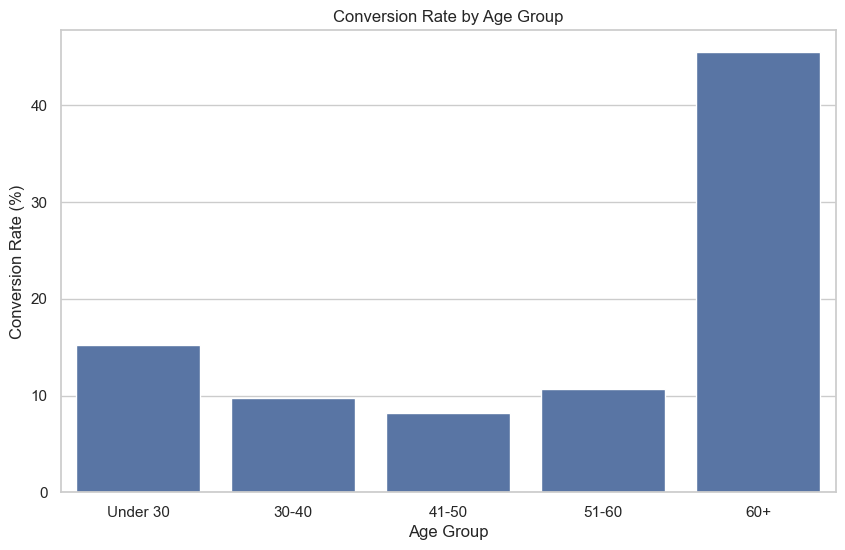

In [47]:
# Create bar chart: conversion rate by age group
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_conversion,
    x='age_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')

plt.show()


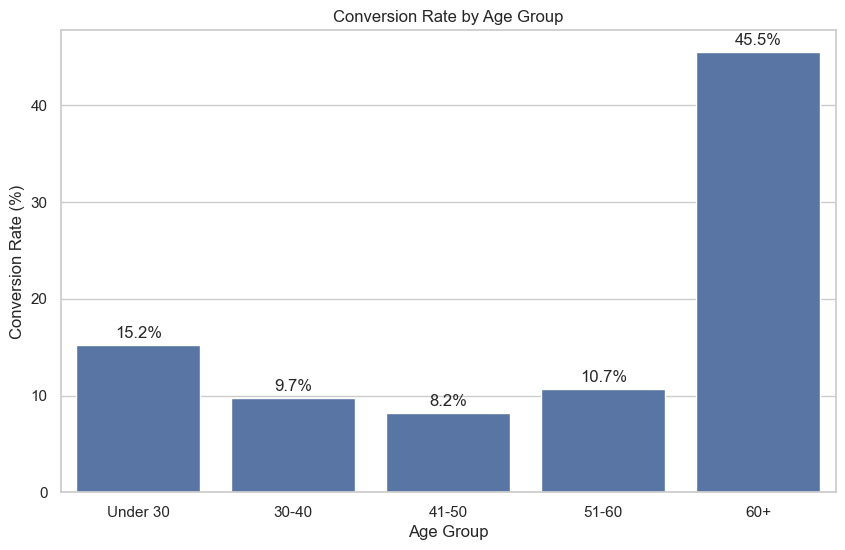

In [63]:
# Polished chart: conversion rate by age group with value labels
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_conversion,
    x='age_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate (%)')

# Add percentage labels on top of each bar
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.1f%%', padding=3)

plt.show()


### Visualization Insight: Conversion Rate by Age Group

The bar chart shows that the 60+ customer group has a much higher conversion rate than all other age groups.

This suggests that senior customers may be more responsive to term deposit offers, possibly because they may prioritize savings stability, lower-risk financial products, or retirement-related planning.

Although this group is smaller in volume, it is highly conversion-efficient.


In [49]:
# Recreate campaign contact frequency groups
df['campaign_contact_group'] = pd.cut(
    df['campaign'],
    bins=[0, 1, 3, 5, 100],
    labels=['1 Contact', '2-3 Contacts', '4-5 Contacts', '6+ Contacts']
)

# Confirm the column was created
df['campaign_contact_group'].value_counts().sort_index()



campaign_contact_group
1 Contact       17642
2-3 Contacts    15911
4-5 Contacts     4250
6+ Contacts      3385
Name: count, dtype: int64

In [50]:
# Analyze conversion rate by campaign contact group
contact_conversion = df.groupby('campaign_contact_group', observed=True).agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
contact_conversion['conversion_rate'] = contact_conversion['conversion_rate'] * 100

# Show the result
contact_conversion


,campaign_contact_group,total_customers,converted_customers,conversion_rate
0,1 Contact,17642,2300,13.037071
1,2-3 Contacts,15911,1785,11.218654
2,4-5 Contacts,4250,369,8.682353
3,6+ Contacts,3385,186,5.494830


### Conversion Insight: Campaign Contact Frequency

Customers contacted only once have the highest conversion rate at approximately 13.04%.

As the number of campaign contacts increases, the conversion rate decreases. Customers contacted 6 or more times show the lowest conversion rate.

This suggests that repeated contact attempts may not improve conversion efficiency and could indicate lower customer interest or campaign fatigue.

From a campaign strategy perspective, the business should focus on improving early-contact effectiveness rather than relying heavily on repeated outreach.


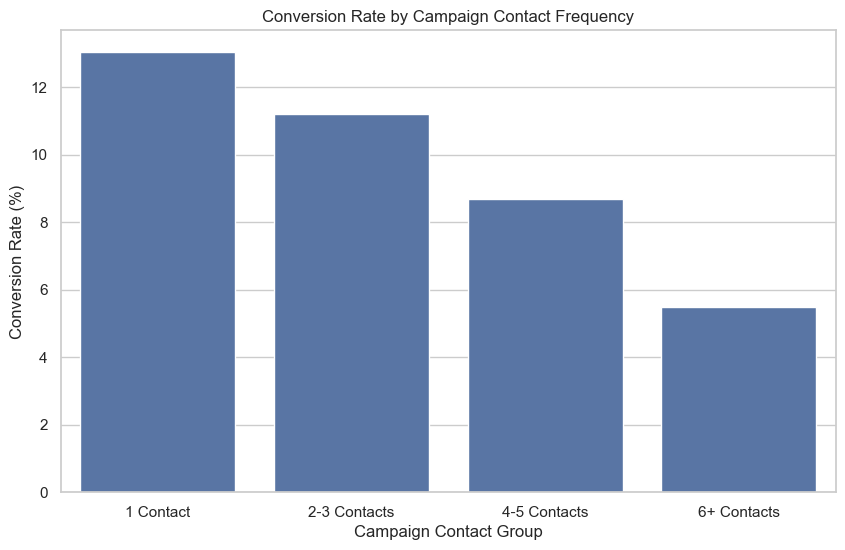

In [51]:
# Create bar chart: conversion rate by campaign contact group
plt.figure(figsize=(10, 6))

sns.barplot(
    data=contact_conversion,
    x='campaign_contact_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Campaign Contact Frequency')
plt.xlabel('Campaign Contact Group')
plt.ylabel('Conversion Rate (%)')

plt.show()


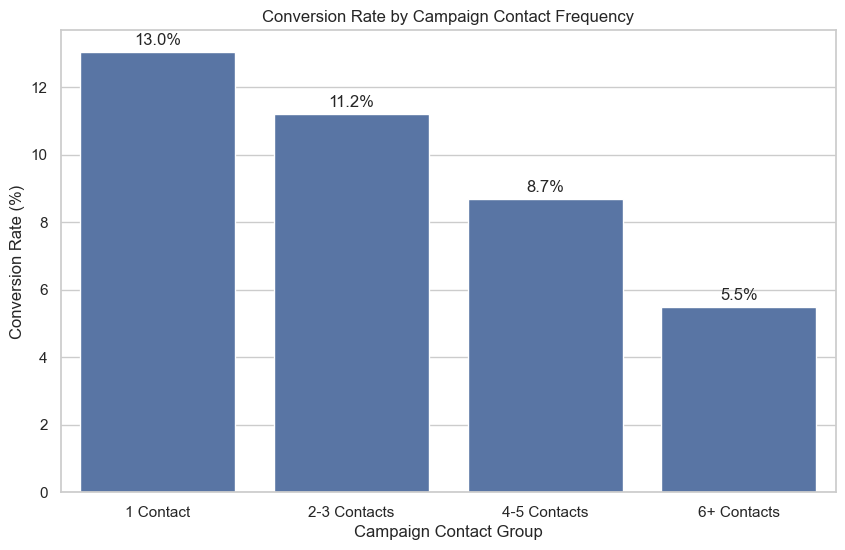

In [64]:
# Polished chart: conversion rate by campaign contact frequency with value labels
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=contact_conversion,
    x='campaign_contact_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Campaign Contact Frequency')
plt.xlabel('Campaign Contact Group')
plt.ylabel('Conversion Rate (%)')

# Add percentage labels on top of each bar
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.1f%%', padding=3)

plt.show()


### Visualization Insight: Contact Frequency vs Conversion

The chart shows a clear downward pattern in conversion rate as campaign contact frequency increases.

Customers contacted once show the strongest conversion performance, while customers contacted 6 or more times show the weakest conversion performance.

This supports the idea that effective targeting and early-contact quality may matter more than repeated outreach volume.


In [52]:
# Recreate previous contact status if needed
df['previous_contact_status'] = np.where(
    df['previous'] > 0,
    'Previously Contacted',
    'No Previous Contact'
)

# Analyze conversion rate by previous contact status
previous_contact_conversion = df.groupby('previous_contact_status').agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
previous_contact_conversion['conversion_rate'] = previous_contact_conversion['conversion_rate'] * 100

# Show the result
previous_contact_conversion


,previous_contact_status,total_customers,converted_customers,conversion_rate
0,No Previous Contact,35563,3141,8.832213
1,Previously Contacted,5625,1499,26.648889


### Conversion Insight: Previous Contact Status

Previously contacted customers show a much higher conversion rate at approximately 26.65%, compared with 8.83% for customers with no previous contact.

This suggests that prior campaign exposure or customer familiarity may improve conversion performance.

From a business perspective, re-engagement campaigns may be highly valuable when targeted carefully.



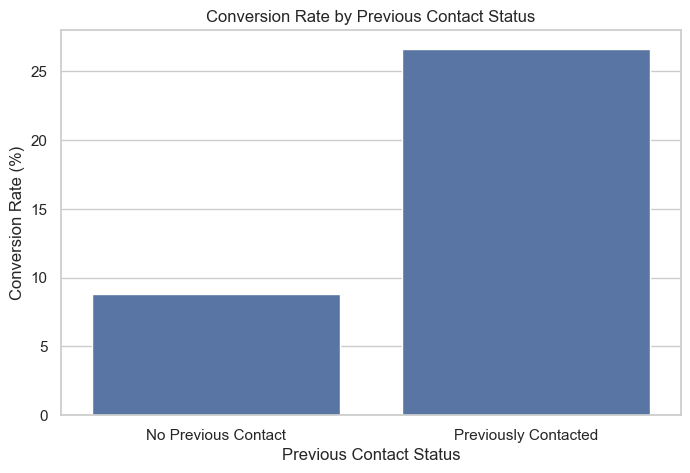

In [53]:
# Create bar chart: conversion rate by previous contact status
plt.figure(figsize=(8, 5))

sns.barplot(
    data=previous_contact_conversion,
    x='previous_contact_status',
    y='conversion_rate'
)

plt.title('Conversion Rate by Previous Contact Status')
plt.xlabel('Previous Contact Status')
plt.ylabel('Conversion Rate (%)')

plt.show()


### Visualization Insight: Previous Contact Status

The chart shows a strong conversion difference between customers with previous contact history and customers with no previous contact.

Previously contacted customers convert at a much higher rate, suggesting that familiarity, prior engagement, or campaign memory may support better marketing outcomes.

This insight can support a re-engagement strategy for customers with prior campaign exposure.


In [54]:
# Recreate previous campaign outcome group if needed
df['previous_outcome_group'] = df['poutcome'].replace({
    'success': 'Previous Success',
    'failure': 'Previous Failure',
    'nonexistent': 'No Previous Campaign'
})

# Analyze conversion rate by previous campaign outcome group
previous_outcome_conversion = df.groupby('previous_outcome_group').agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
previous_outcome_conversion['conversion_rate'] = previous_outcome_conversion['conversion_rate'] * 100

# Sort by conversion rate from highest to lowest
previous_outcome_conversion = previous_outcome_conversion.sort_values(
    by='conversion_rate',
    ascending=False
)

# Show the result
previous_outcome_conversion


,previous_outcome_group,total_customers,converted_customers,conversion_rate
2,Previous Success,1373,894,65.112891
1,Previous Failure,4252,605,14.228598
0,No Previous Campaign,35563,3141,8.832213


### Conversion Insight: Previous Campaign Outcome

Customers with a previous successful campaign outcome have the highest conversion rate at approximately 65.11%.

This is significantly higher than customers with previous campaign failure or no previous campaign history.

This suggests that previous campaign success is a strong indicator of future conversion potential.

From a marketing strategy perspective, customers with prior successful engagement should be treated as a high-priority reactivation or upsell audience.


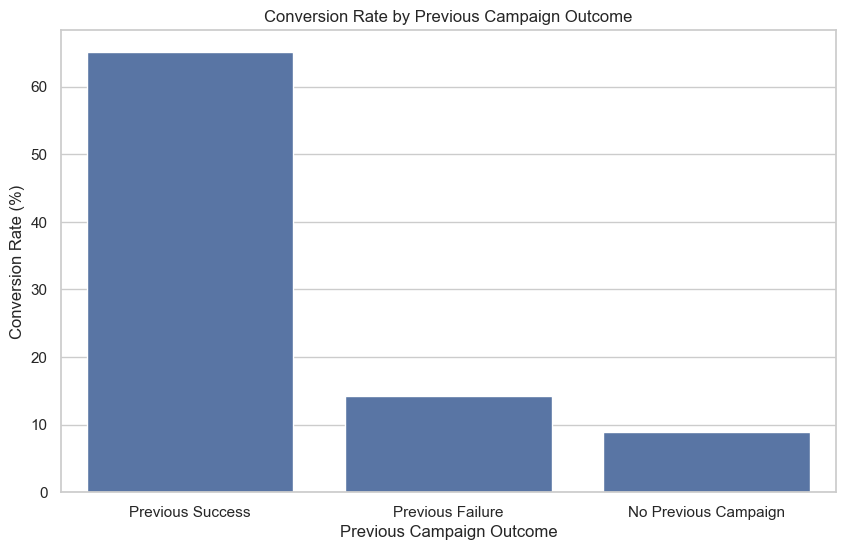

In [55]:
# Create bar chart: conversion rate by previous campaign outcome
plt.figure(figsize=(10, 6))

sns.barplot(
    data=previous_outcome_conversion,
    x='previous_outcome_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Conversion Rate (%)')

plt.show()


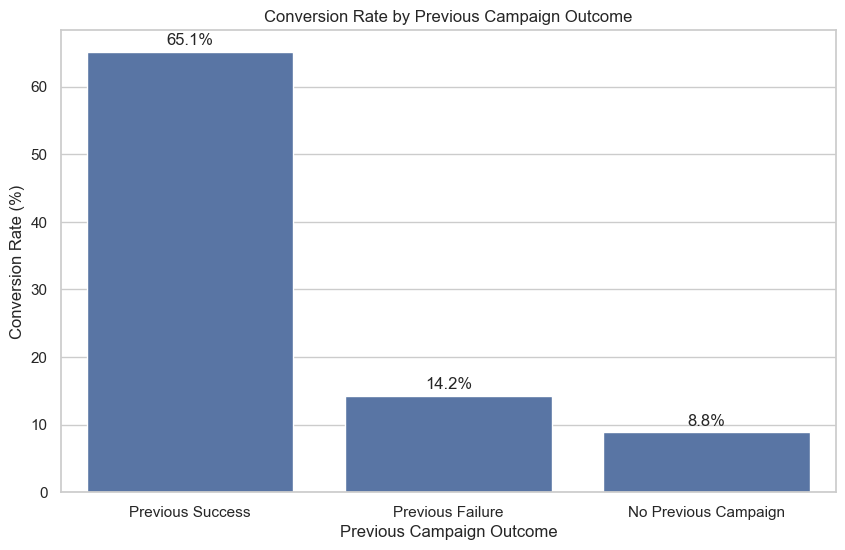

In [65]:
# Polished chart: conversion rate by previous campaign outcome with value labels
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=previous_outcome_conversion,
    x='previous_outcome_group',
    y='conversion_rate'
)

plt.title('Conversion Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Conversion Rate (%)')

# Add percentage labels on top of each bar
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.1f%%', padding=3)

plt.show()


### Visualization Insight: Previous Campaign Outcome

The chart shows that customers with a previous successful campaign outcome have a much higher conversion rate than all other groups.

This indicates that historical campaign performance can be used as a valuable signal for future targeting.

Customers with previous success should be prioritized for reactivation, cross-sell, or personalized follow-up strategies.


In [56]:
# Analyze conversion rate by job type
job_conversion = df.groupby('job').agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
job_conversion['conversion_rate'] = job_conversion['conversion_rate'] * 100

# Sort by conversion rate from highest to lowest
job_conversion = job_conversion.sort_values(
    by='conversion_rate',
    ascending=False
)

# Show the result
job_conversion


,job,total_customers,converted_customers,conversion_rate
8,student,875,275,31.428571
5,retired,1720,434,25.232558
10,unemployed,1014,144,14.201183
0,admin.,10422,1352,12.972558
4,management,2924,328,11.217510
11,unknown,330,37,11.212121
9,technician,6743,730,10.826042
6,self-employed,1421,149,10.485574
3,housemaid,1060,106,10.000000
2,entrepreneur,1456,124,8.516484


### Conversion Insight: Job Type

Students have the highest conversion rate at approximately 31.43%, followed by retired customers at approximately 25.23%.

This suggests that certain life-stage or occupation groups may be more responsive to term deposit offers.

Although admin and blue-collar customers have larger customer volumes, their conversion rates are lower than students and retired customers.

From a marketing perspective, occupation-based targeting can help improve campaign efficiency by prioritizing groups with stronger conversion behavior.


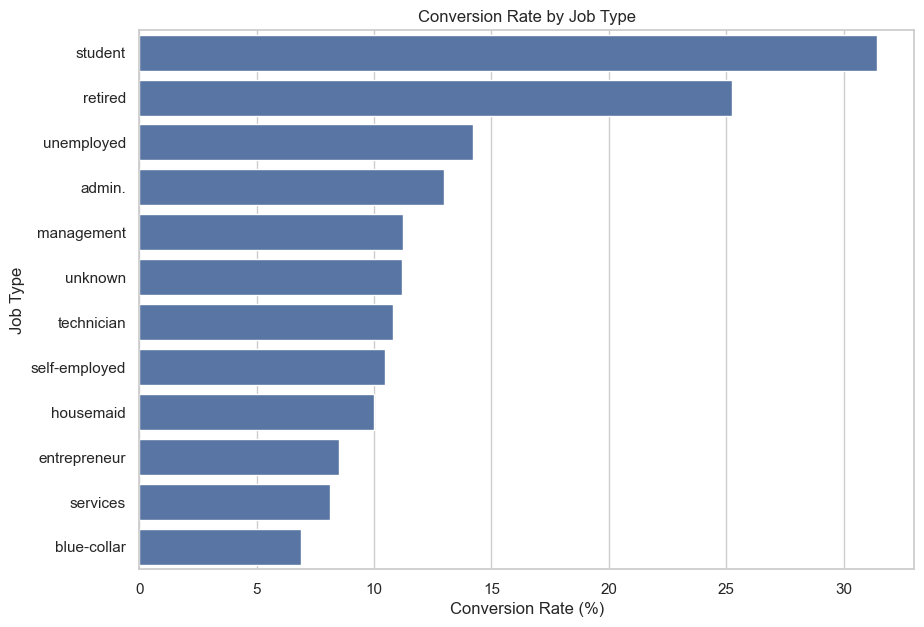

In [57]:
# Create horizontal bar chart: conversion rate by job type
plt.figure(figsize=(10, 7))

sns.barplot(
    data=job_conversion,
    x='conversion_rate',
    y='job'
)

plt.title('Conversion Rate by Job Type')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Job Type')

plt.show()


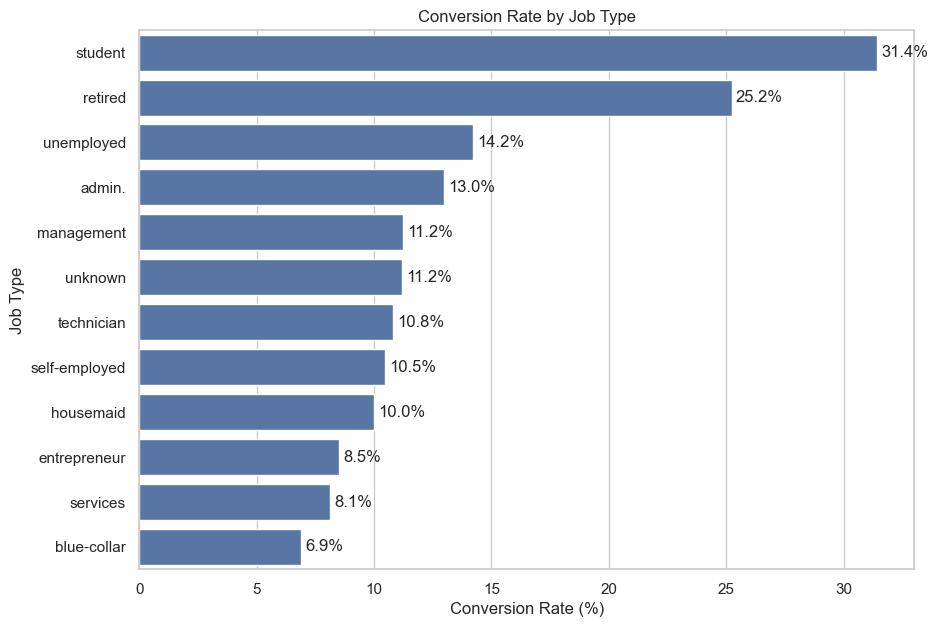

In [66]:
# Polished chart: conversion rate by job type with value labels
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=job_conversion,
    x='conversion_rate',
    y='job'
)

plt.title('Conversion Rate by Job Type')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Job Type')

# Add percentage labels at the end of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.show()


### Visualization Insight: Job Type

The job conversion chart shows that students and retired customers have the highest conversion rates.

This suggests that occupation and life stage may influence customer response to term deposit campaigns.

Lower-converting groups such as blue-collar and services may require different messaging, stronger offer positioning, or more selective targeting.


In [58]:
# Analyze conversion rate by education level
education_conversion = df.groupby('education').agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
education_conversion['conversion_rate'] = education_conversion['conversion_rate'] * 100

# Sort by conversion rate from highest to lowest
education_conversion = education_conversion.sort_values(
    by='conversion_rate',
    ascending=False
)

# Show the result
education_conversion



,education,total_customers,converted_customers,conversion_rate
4,illiterate,18,4,22.222222
7,unknown,1731,251,14.500289
6,university.degree,12168,1670,13.724523
5,professional.course,5243,595,11.348465
3,high.school,9515,1031,10.835523
0,basic.4y,4176,428,10.249042
1,basic.6y,2292,188,8.202443
2,basic.9y,6045,473,7.824648


### Conversion Insight: Education Level

The `illiterate` group shows the highest conversion rate, but the group size is very small with only 18 customers. Because of this small sample size, it should not be treated as a major strategic segment.

Among larger education groups, customers with a university degree show stronger conversion performance.

This suggests that education level may have some relationship with campaign response, but business recommendations should focus on both conversion rate and customer volume.


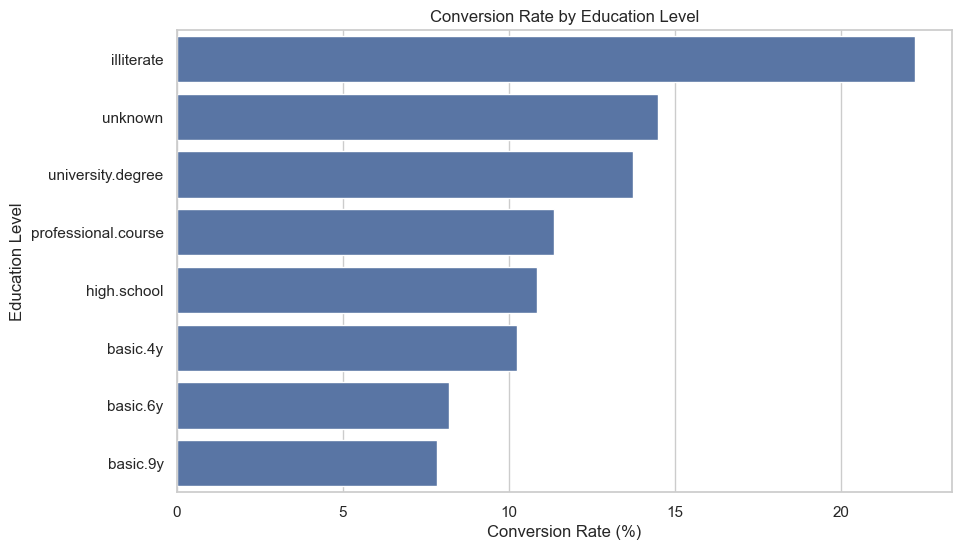

In [59]:
# Create horizontal bar chart: conversion rate by education level
plt.figure(figsize=(10, 6))

sns.barplot(
    data=education_conversion,
    x='conversion_rate',
    y='education'
)

plt.title('Conversion Rate by Education Level')
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Education Level')

plt.show()


### Visualization Insight: Education Level

The education chart shows variation in conversion rates across education groups.

Although the `illiterate` category has the highest percentage, the customer count is very small, so it should be interpreted carefully.

Among larger groups, university-degree customers show relatively stronger conversion performance, making them more useful for business interpretation.


In [60]:
# Analyze conversion rate by campaign month
month_conversion = df.groupby('month').agg(
    total_customers=('conversion_flag', 'count'),
    converted_customers=('conversion_flag', 'sum'),
    conversion_rate=('conversion_flag', 'mean')
).reset_index()

# Convert conversion rate into percentage
month_conversion['conversion_rate'] = month_conversion['conversion_rate'] * 100

# Sort by conversion rate from highest to lowest
month_conversion = month_conversion.sort_values(
    by='conversion_rate',
    ascending=False
)

# Show the result
month_conversion


,month,total_customers,converted_customers,conversion_rate
5,mar,546,276,50.549451
2,dec,182,89,48.901099
9,sep,570,256,44.912281
8,oct,718,315,43.871866
0,apr,2632,539,20.478723
1,aug,6178,655,10.602137
4,jun,5318,559,10.511470
7,nov,4101,416,10.143867
3,jul,7174,649,9.046557
6,may,13769,886,6.434745


### Conversion Insight: Campaign Month

Campaign conversion rates vary significantly by month.

March, December, September, and October show the highest conversion rates, while May has the largest customer volume but a much lower conversion rate.

This suggests that campaign timing may play an important role in conversion performance.

From a business perspective, the marketing team should evaluate whether high-performing months had better targeting, stronger customer intent, different economic conditions, or more effective campaign execution.


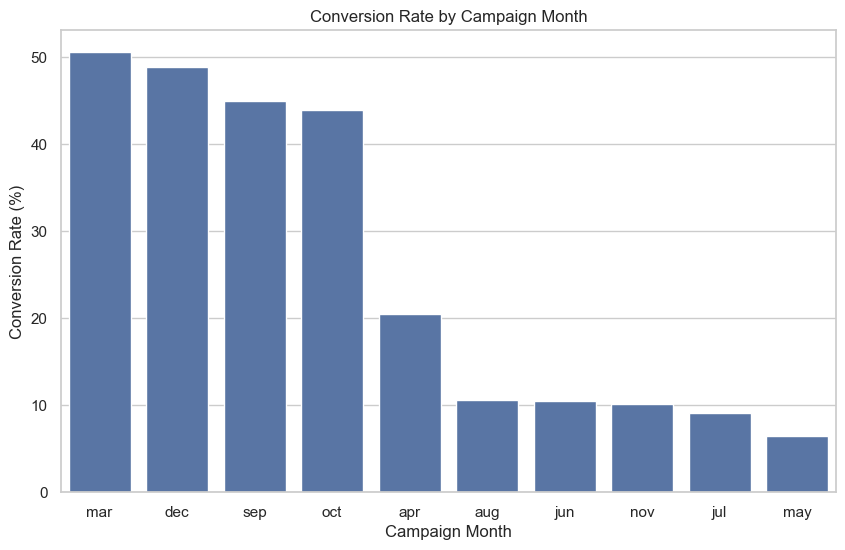

In [61]:
# Create bar chart: conversion rate by campaign month
plt.figure(figsize=(10, 6))

sns.barplot(
    data=month_conversion,
    x='month',
    y='conversion_rate'
)

plt.title('Conversion Rate by Campaign Month')
plt.xlabel('Campaign Month')
plt.ylabel('Conversion Rate (%)')

plt.show()


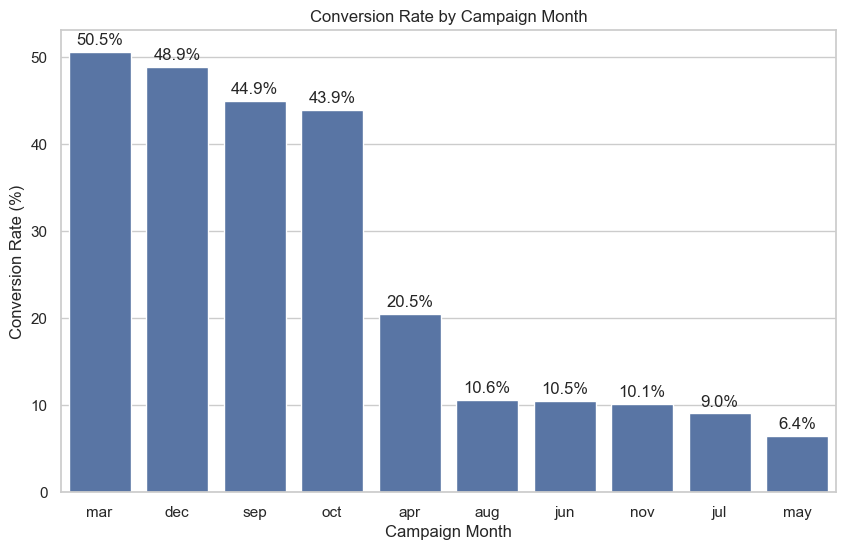

In [67]:
# Polished chart: conversion rate by campaign month with value labels
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=month_conversion,
    x='month',
    y='conversion_rate'
)

plt.title('Conversion Rate by Campaign Month')
plt.xlabel('Campaign Month')
plt.ylabel('Conversion Rate (%)')

# Add percentage labels on top of each bar
for bar in ax.containers:
    ax.bar_label(bar, fmt='%.1f%%', padding=3)

plt.show()


### Visualization Insight: Campaign Month

The month-level chart shows that conversion performance is not evenly distributed across the year.

March, December, September, and October have much stronger conversion rates, while May has the weakest conversion rate despite having the largest customer volume.

This reinforces the idea that campaign timing and customer readiness may strongly influence conversion outcomes.


In [62]:
# Create a summary table of key business insights
business_insights = pd.DataFrame({
    'analysis_area': [
        'Overall Campaign',
        'Age Group',
        'Contact Frequency',
        'Previous Contact Status',
        'Previous Campaign Outcome',
        'Job Type',
        'Campaign Month'
    ],
    'key_finding': [
        'Overall conversion rate is 11.27%',
        '60+ customers have the highest conversion rate',
        'Conversion decreases as contact frequency increases',
        'Previously contacted customers convert much better',
        'Previous campaign success is the strongest conversion signal',
        'Students and retired customers show the highest conversion rates',
        'March, December, September, and October perform best'
    ],
    'business_meaning': [
        'The campaign converts roughly 11 customers per 100 contacts',
        'Smaller senior segment is highly conversion-efficient',
        'Repeated outreach may indicate lower interest or campaign fatigue',
        'Re-engagement audiences may be valuable',
        'Past success can guide future targeting',
        'Occupation and life stage influence campaign response',
        'Campaign timing may influence customer readiness'
    ]
})

business_insights


,analysis_area,key_finding,business_meaning
0,Overall Campaign,Overall conversion rate is 11.27%,The campaign converts roughly 11 customers per...
1,Age Group,60+ customers have the highest conversion rate,Smaller senior segment is highly conversion-ef...
2,Contact Frequency,Conversion decreases as contact frequency incr...,Repeated outreach may indicate lower interest ...
3,Previous Contact Status,Previously contacted customers convert much be...,Re-engagement audiences may be valuable
4,Previous Campaign Outcome,Previous campaign success is the strongest con...,Past success can guide future targeting
5,Job Type,Students and retired customers show the highes...,Occupation and life stage influence campaign r...
6,Campaign Month,"March, December, September, and October perfor...",Campaign timing may influence customer readiness


## Business Insights Summary

The analysis shows that campaign conversion is influenced by customer profile, campaign history, contact strategy, and campaign timing.

Key insights include:

- The overall campaign conversion rate is 11.27%.
- Senior customers, especially the 60+ group, show the highest conversion rate.
- Customers contacted only once convert better than customers contacted many times.
- Previously contacted customers convert much better than customers with no prior contact.
- Previous campaign success is the strongest conversion signal.
- Students and retired customers show the highest conversion rates by occupation.
- Campaign timing varies significantly, with March, December, September, and October showing stronger conversion performance.

Overall, the campaign should not be evaluated only by contact volume. Conversion efficiency is driven by the quality of targeting, customer readiness, and prior engagement history.


## Analytical Limitations

This analysis is based on historical campaign data and should be interpreted as descriptive business intelligence, not as a predictive model.

Important limitations:

- The dataset does not include a unique customer ID, so each row is treated as a campaign contact record.
- The `duration` column is useful for descriptive engagement analysis but should not be used for pre-campaign prediction because it is only known after the call.
- Some categories have small sample sizes, so high conversion rates in very small groups should be interpreted carefully.
- External business factors such as interest rates, customer financial goals, and broader economic conditions may also influence conversion behavior.

These limitations do not reduce the value of the analysis, but they help define how the insights should be used responsibly.


## Strategic Recommendations

Based on the analysis, the following recommendations can improve marketing conversion and funnel efficiency:

### 1. Prioritize high-intent re-engagement audiences

Customers with previous campaign success show the strongest conversion rate. These customers should be prioritized for reactivation, upsell, or personalized follow-up campaigns.

### 2. Improve early-contact effectiveness

Customers contacted once have the highest conversion rate, while conversion decreases with repeated contact attempts. The business should focus on improving the first-contact experience instead of relying heavily on repeated outreach.

### 3. Build segment-specific campaign strategies

Students, retired customers, and senior customers show stronger conversion behavior. These groups may benefit from tailored messaging based on life stage, savings goals, and financial planning needs.

### 4. Review campaign timing strategy

March, December, September, and October show stronger conversion performance. The business should investigate whether seasonality, economic conditions, or campaign execution differences contributed to this performance.

### 5. Balance volume with conversion efficiency

Large customer groups do not always produce the highest conversion rates. Future campaigns should balance audience size with conversion efficiency to improve return on marketing effort.


## Executive Conclusion

This notebook analyzed the UCI Bank Marketing dataset to understand marketing conversion behavior and identify strategic opportunities for funnel improvement.

The campaign achieved an overall conversion rate of 11.27%, with major differences across customer segments, campaign history, contact frequency, occupation, and campaign month.

The strongest conversion signals were previous campaign success, previous contact history, senior age groups, and specific occupation segments such as students and retired customers.

The analysis also showed that higher outreach frequency does not necessarily improve conversion. Customers contacted only once had the strongest conversion performance, while repeated contact groups showed lower conversion rates.

From a business intelligence perspective, the key opportunity is to move from volume-based campaign execution toward targeted, insight-driven campaign strategy.

This notebook complements the Power BI dashboard by providing the analytical reasoning, feature engineering, exploratory analysis, and business interpretation behind the executive-level visuals.


## Portfolio Value Statement

This notebook demonstrates the backend analytical workflow behind an executive Power BI dashboard.

It shows the ability to:

- Understand and structure a business analytics problem
- Prepare and engineer meaningful analytical features
- Calculate conversion and funnel KPIs
- Compare customer and campaign segments
- Build clear visualizations using Python
- Translate data patterns into business insights
- Recommend practical marketing actions

Together with the Power BI dashboard, this notebook presents a complete analytics portfolio project that combines technical analysis, business intelligence thinking, and executive storytelling.
